# 최종 실습 프로젝트

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False
plt.rc("font", family="Malgun Gothic")

### **프로젝트 개요**

 당신은 한 온라인 쇼핑몰의 데이터 분석가로 고용되었다. 쇼핑몰의 판매 데이터를 분석하여 고객의 구매 패턴을 파악하고, 중요한 인사이트를 도출하는 것이 이번 프로젝트의 목표다. 이를 통해 향후 마케팅 전략을 제시하고자 한다.

[ecommerce_sales_data.csv](https://prod-files-secure.s3.us-west-2.amazonaws.com/7f69c78b-7b53-4fc6-a50d-5df3abdafd0c/2cbd720f-a738-4f1c-a078-ef3696397460/ecommerce_sales_data.csv)

주어진 데이터는 고객의 주문 기록, 상품 정보, 판매 데이터 등을 포함하고 있다. 주어진 데이터를 분석하여 아래의 질문에 답하라.

</aside>

- **데이터 파일**: `ecommerce_sales_data.csv`
- **데이터 설명**:
    - **OrderID**: 주문 ID
    - **Product**: 주문한 상품 이름
    - **Category**: 상품의 카테고리 (예: Electronics, Clothing 등)
    - **Quantity**: 주문 수량
    - **Price**: 상품의 가격
    - **CustomerID**: 고객 ID
    - **BirthDate**: 고객 생일
    - **OrderDate**: 주문 날짜
    - **Country**: 주문한 고객의 국가
- **문제**
    1. **데이터 탐색 및 전처리**
        1. 데이터셋을 로드하고 상위 5개의 데이터를 출력하세요.
        2. 결측값이 있는 열이 있는지 확인하고, 결측값이 있는 경우 적절한 방법으로 처리하세요.
        3. 각 열의 데이터 타입을 확인하고, **OrderDate** 열을 datetime 형식으로 변환하세요.
    2. **매출 분석**
        1. **매출액**(총 판매 금액)을 계산하는 새로운 열 `TotalRevenue`를 생성하세요.
            - 매출액 = `Quantity` * `Price`
        2. 월별 총 매출액을 집계하여 시각화하세요.
            - 힌트: `resample()`을 사용하여 월별로 데이터를 집계하세요.
        3. 카테고리별로 매출액이 가장 높은 상위 3개의 카테고리를 구하세요.
            - 힌트: `largest()` 사용
        4. 국가별 총 매출액을 계산하고, 매출액이 가장 높은 5개 국가를 출력하세요.
    3. **고객 분석**
        1. 고객별로 총 매출액을 계산한 후, 상위 5명의 고객을 출력하세요.
        2. 주문 횟수가 가장 많은 상위 5명의 고객을 출력하세요.
    4. **상품 분석**
        1. 가장 많이 판매된 상위 5개의 상품을 출력하세요.
        2. **카테고리별**로 가장 많이 판매된 상품을 찾아 출력하세요.
            - 힌트: `agg()`에 `lambda`사용
            - 힌트: `idmax()` → 최댓값을 가진 행의 **index를 반환하는 메서드**
        3. **평균 구매 수량**이 가장 높은 상위 3개의 상품을 출력하세요.
    5. **시간 분석**
        1. 주문 날짜별로 **주별** 매출액을 계산하고 시각화하세요.
        2. 특정 기간(예: 2024년 1월 ~ 2024년 6월) 동안의 매출 추이를 분석하고 시각화하세요.
        3. 특정 국가에서 가장 많이 주문한 시간대를 분석하고, 이를 시각화하여 인사이트를 도출하세요.
    6. **추가 분석**
        1. 고객의 **재구매율**을 분석하세요.
            - 재구매율 = 한 고객이 여러 번 주문한 비율

---
---

#### 1. **데이터 탐색 및 전처리**
    1. 데이터셋을 로드하고 상위 5개의 데이터를 출력하세요.

In [46]:
df=pd.read_csv("ecommerce_sales_data.csv")
df.head(5)

,OrderID,Product,Category,Quantity,Price,CustomerID,Birthdate,OrderDate,Country
0,1,역사책,Books,5,37000,1071,1980-08-08,2024-06-10 17:18,미국
1,2,셔츠,Clothing,5,20000,1526,1967-08-09,2023-11-18 18:45,독일
2,3,노트북,Electronics,4,8000,1252,1973-04-07,2023-10-15 11:19,중국
3,4,자전거,Sports,1,8000,1670,1970-04-08,2024-07-19 2:19,일본
4,5,헤드폰,Electronics,3,26000,1838,1992-05-19,2024-01-20 20:34,대한민국


    2. 결측값이 있는 열이 있는지 확인하고, 결측값이 있는 경우 적절한 방법으로 처리하세요.

In [47]:
df.isnull().sum()

OrderID       0
Product       0
Category      0
Quantity      0
Price         0
CustomerID    0
Birthdate     0
OrderDate     0
Country       0
dtype: int64

    3. 각 열의 데이터 타입을 확인하고, **OrderDate** 열을 datetime 형식으로 변환하세요.

In [48]:
df.info()
df["OrderDate"]=pd.to_datetime(df["OrderDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   OrderID     120 non-null    int64 
 1   Product     120 non-null    object
 2   Category    120 non-null    object
 3   Quantity    120 non-null    int64 
 4   Price       120 non-null    int64 
 5   CustomerID  120 non-null    int64 
 6   Birthdate   120 non-null    object
 7   OrderDate   120 non-null    object
 8   Country     120 non-null    object
dtypes: int64(4), object(5)
memory usage: 8.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OrderID     120 non-null    int64         
 1   Product     120 non-null    object        
 2   Category    120 non-null    object        
 3   Quantity    120 non-null    int64         
 4   Price    

---
---

#### 2. **매출 분석**

    1. **매출액**(총 판매 금액)을 계산하는 새로운 열 `TotalRevenue`를 생성하세요.
        - 매출액 = `Quantity` * `Price`

In [49]:
df["TotalRevenue"]=df["Quantity"]*df["Price"]
df.head()

,OrderID,Product,Category,Quantity,Price,CustomerID,Birthdate,OrderDate,Country,TotalRevenue
0,1,역사책,Books,5,37000,1071,1980-08-08,2024-06-10 17:18:00,미국,185000
1,2,셔츠,Clothing,5,20000,1526,1967-08-09,2023-11-18 18:45:00,독일,100000
2,3,노트북,Electronics,4,8000,1252,1973-04-07,2023-10-15 11:19:00,중국,32000
3,4,자전거,Sports,1,8000,1670,1970-04-08,2024-07-19 02:19:00,일본,8000
4,5,헤드폰,Electronics,3,26000,1838,1992-05-19,2024-01-20 20:34:00,대한민국,78000


    2. 월별 총 매출액을 집계하여 시각화하세요.
        - 힌트: `resample()`을 사용하여 월별로 데이터를 집계하세요.

In [50]:
df.set_index('OrderDate', inplace=True)
monthly_sales=df.resample('ME').sum()

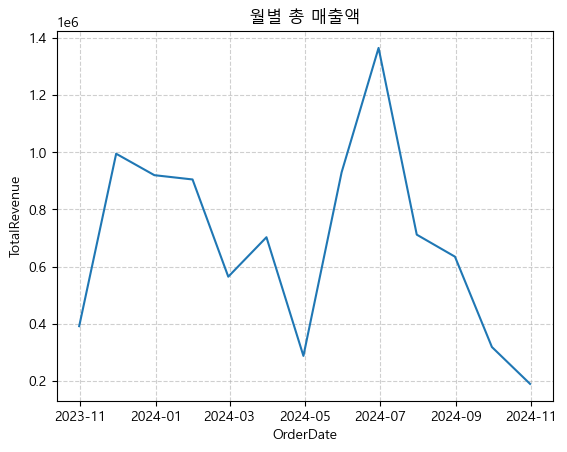

In [51]:
sns.lineplot(data=monthly_sales, x="OrderDate", y="TotalRevenue")
plt.title("월별 총 매출액")
plt.grid(True, linestyle="--", alpha=0.6)

    3. 카테고리별로 매출액이 가장 높은 상위 3개의 카테고리를 구하세요.
        - 힌트: `nlargest()` 사용

In [52]:
df.groupby(["Category"])[["TotalRevenue"]].sum().nlargest(3,"TotalRevenue","all")

,TotalRevenue
Category,
Food,1966000
Electronics,1746000
Beauty,1493000


    4. 국가별 총 매출액을 계산하고, 매출액이 가장 높은 5개 국가를 출력하세요.

In [53]:
df.groupby(["Country"])[["TotalRevenue"]].sum().nlargest(5,"TotalRevenue",keep='all')

,TotalRevenue
Country,
미국,2238000
독일,1973000
중국,1766000
일본,1523000
대한민국,1419000


---
---

#### 3. **고객 분석**

    1. 고객별로 총 매출액을 계산한 후, 상위 5명의 고객을 출력하세요.

In [ ]:
df.groupby(["CustomerID"])[["TotalRevenue"]].sum().sort_values(
    "TotalRevenue",axis=0, ascending=False).head(5)

,TotalRevenue
CustomerID,
1007,334000
1354,245000
1141,241000
1589,215000
1632,192000


    2. 주문 횟수가 가장 많은 상위 5명의 고객을 출력하세요.

In [55]:
df.groupby(["CustomerID"])["OrderID"].count().nlargest(5, "first")

CustomerID
1007    2
1038    2
1141    2
1206    2
1278    2
Name: OrderID, dtype: int64

---
---

#### 4. **상품 분석**

    1. 가장 많이 판매된 상위 5개의 상품을 출력하세요.

In [56]:
df["Product"].value_counts().head(5)
df.groupby(["Product"])[["Quantity"]].sum().sort_values(by="Quantity", ascending=False).head(5)

,Quantity
Product,
셔츠,25
립스틱,22
소설,21
커피,20
역사책,20


    2. **카테고리별**로 가장 많이 판매된 상품을 찾아 출력하세요.
        - 힌트: `agg()`에 `lambda`사용
        - 힌트: `idxmax()` → 최댓값을 가진 행의 **index를 반환하는 메서드**

In [57]:
# groupby로 그룹화 후, 인덱스화 된 Category를 .reset_index()로 인덱스 해제하여 평면 상태로 되돌림
product_by_sales=df.groupby(["Category","Product"])[["Quantity"]].sum().reset_index()
# 각 그룹에서 수량이 최대인 '위치(인덱스)의 이름'을 'Quantity'에 반환
product_max_index=product_by_sales.groupby('Category').agg({'Quantity' : lambda x: x.idxmax()})
# '찾은 이름'으로 해당 값을 찾아옴
result = product_by_sales.loc[product_max_index['Quantity']]
result


,Category,Product,Quantity
1,Beauty,립스틱,22
7,Books,소설,21
10,Clothing,셔츠,25
14,Electronics,노트북,15
23,Food,커피,20
25,Sports,요가매트,12


    3. **평균 구매 수량**이 가장 높은 상위 3개의 상품을 출력하세요.

In [58]:
df.groupby(["Product"])[["Quantity"]].mean().nlargest(n=3, columns="Quantity")

,Quantity
Product,
자기계발,5.0
주스,5.0
요가매트,4.0


---
---

#### 5. **시간 분석**

    1. 주문 날짜별로 **주별** 매출액을 계산하고 시각화하세요.

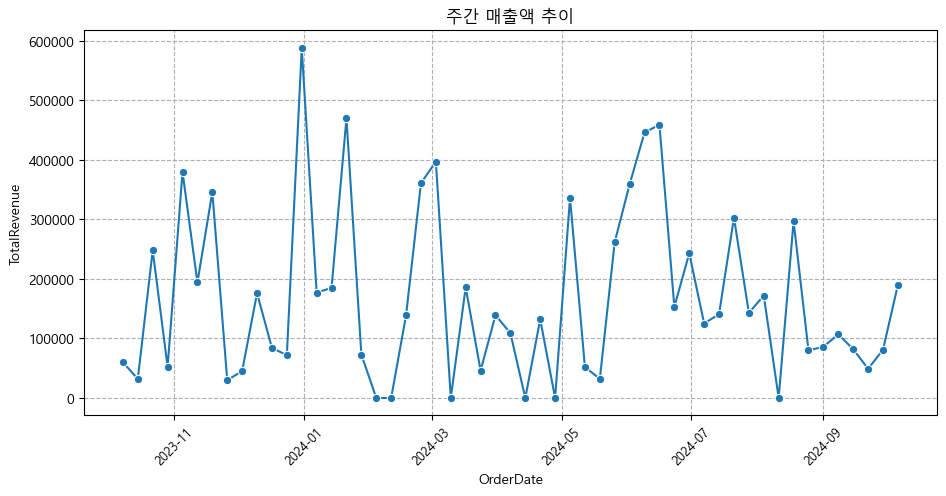

In [59]:
import matplotlib.dates as mdates
weekly_trend=df.sort_index(axis=0).resample("W")["TotalRevenue"].sum().reset_index()
plt.figure(figsize=(11,5))
sns.lineplot(data=weekly_trend, x="OrderDate", y="TotalRevenue", marker='o')
plt.title("주간 매출액 추이")
plt.xticks(rotation=45, fontsize=9)
plt.grid(visible=True, linestyle="--", axis="both")

    2. 특정 기간(예: 2024년 1월 ~ 2024년 6월) 동안의 매출 추이를 분석하고 시각화하세요.

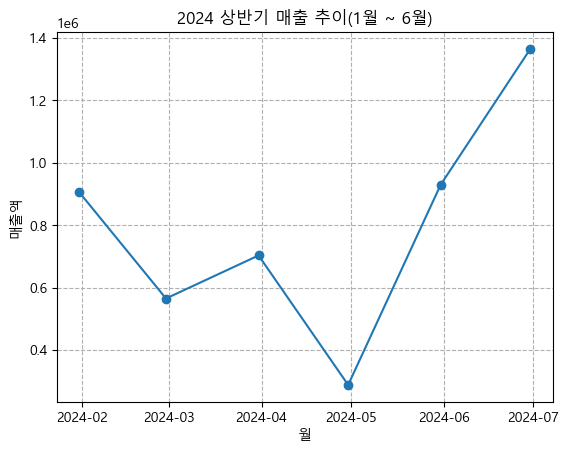

In [60]:
df_sorted=df.sort_values(by="OrderDate",axis=0)
df_24Q1Q2=df_sorted['2024-01':'2024-06']
monthly_trend=df_24Q1Q2.resample('ME')['TotalRevenue'].sum().reset_index()
plt.plot(monthly_trend["OrderDate"], monthly_trend["TotalRevenue"], marker="o")
plt.title("2024 상반기 매출 추이(1월 ~ 6월)")
plt.xlabel("월")
plt.ylabel("매출액")
plt.grid(True, linestyle="--")
plt.show()

    3. 특정 국가에서 가장 많이 주문한 시간대를 분석하고, 이를 시각화하여 인사이트를 도출하세요.

In [61]:
df_sorted['Hour'] = df_sorted.index.hour
df_sorted[['Country', 'Quantity', 'Hour']].head()
korea_df = df_sorted[df_sorted['Country'] == '대한민국']
korea_trend = korea_df.groupby('Hour')['Quantity'].sum().reset_index()

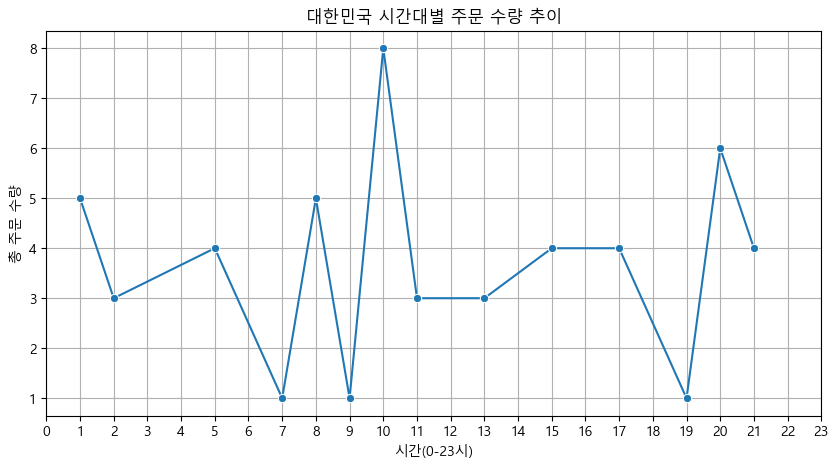

In [62]:
plt.figure(figsize=(10,5))
sns.lineplot(data=korea_trend, x='Hour', y='Quantity', marker='o')
plt.title('대한민국 시간대별 주문 수량 추이')
plt.xlabel('시간(0-23시)')
plt.ylabel('총 주문 수량')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

---
---

#### 6. **추가 분석**

    1. 고객의 **재구매율**을 분석하세요.
        - 재구매율 = 한 고객이 여러 번 주문한 비율

In [63]:
df_sorted

,OrderID,Product,Category,Quantity,Price,CustomerID,Birthdate,Country,TotalRevenue,Hour
OrderDate,,,,,,,,,,
2023-10-08 05:49:00,39,향수,Beauty,4,15000,1941,1980-11-30,대한민국,60000,5
2023-10-15 11:19:00,3,노트북,Electronics,4,8000,1252,1973-04-07,중국,32000,11
2023-10-16 10:11:00,25,노트북,Electronics,3,50000,1982,1998-12-05,미국,150000,10
2023-10-17 05:35:00,19,축구공,Sports,1,9000,1398,1998-12-13,중국,9000,5
2023-10-18 01:49:00,18,축구공,Sports,2,29000,1271,2004-04-06,중국,58000,1
...,...,...,...,...,...,...,...,...,...,...
2024-09-13 07:15:00,74,립스틱,Beauty,2,41000,1777,2004-07-25,중국,82000,7
2024-09-16 17:13:00,13,화장품,Beauty,1,49000,1034,1969-05-13,중국,49000,17
2024-09-28 10:13:00,66,셔츠,Clothing,1,48000,1797,2003-01-09,대한민국,48000,10
